In [5]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

from data_loader import load_options_data
from implied_vol import implied_volatility
from market_maker import MarketMaker

In [6]:
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "spy_options_sample.csv"
)

df = load_options_data(DATA_PATH)

df["implied_vol"] = df.apply(
    lambda row: implied_volatility(
        market_price=row["mid_price"],
        S=row["underlying_price"],
        K=row["strike"],
        T=row["time_to_expiration"],
        r=row["risk_free_rate"],
        option_type=row["option_type"],
        q=0.0,
    ),
    axis=1,
)

df["fair_value"] = df["mid_price"]

df["symbol"] = (
    "SPY_"
    + df["expiration"].dt.strftime("%Y%m%d")
    + "_"
    + df["strike"].astype(int).astype(str)
    + "_"
    + df["option_type"]
)

df[[
    "symbol",
    "fair_value",
    "implied_vol",
    "bid_ask_spread",
    "volume",
]]

,symbol,fair_value,implied_vol,bid_ask_spread,volume
0,SPY_20260220_580_C,25.00,0.133877,0.4,1200
1,SPY_20260220_590_C,17.10,0.127595,0.4,1500
2,SPY_20260320_600_C,10.60,0.080361,0.4,2400
3,SPY_20260420_610_C,6.15,0.061351,0.3,1800
4,SPY_20260420_620_C,3.45,0.067469,0.3,1000
5,SPY_20260420_580_P,4.75,0.120018,0.3,1300
6,SPY_20260520_590_P,7.40,0.109096,0.4,1700
7,SPY_20260620_600_P,10.30,0.099004,0.4,2600
8,SPY_20260620_610_P,14.90,0.100461,0.4,1600
9,SPY_20260620_620_P,20.50,0.102044,0.6,900


In [7]:
market_maker = MarketMaker(
    option_data=df,
    contract_multiplier=100,
    random_seed=42,
)

history = market_maker.run(
    num_updates=1000,
    sample_with_replacement=True,
)

history.head()

,update_number,symbol,strike,option_type,fair_value,market_spread,quoted_bid,quoted_ask,quoted_spread,quote_skew,...,fill_side,fill_price,spread_capture,symbol_position,net_delta,net_vega,cash,market_value,total_equity,total_pnl
0,1,SPY_20260220_580_C,580.0,C,25.00,0.4,24.866531,25.133469,0.266939,0.000000,...,None,NaN,0.000000,0,0.000000,0.00000,0.000000,0.0,0.000000,0.000000
1,2,SPY_20260620_600_P,600.0,P,10.30,0.4,10.175249,10.424751,0.249502,0.000000,...,None,NaN,0.000000,0,0.000000,0.00000,0.000000,0.0,0.000000,0.000000
2,3,SPY_20260520_590_P,590.0,P,7.40,0.4,7.272726,7.527274,0.254548,0.000000,...,None,NaN,0.000000,0,0.000000,0.00000,0.000000,0.0,0.000000,0.000000
3,4,SPY_20260420_620_C,620.0,C,3.45,0.3,3.345633,3.554367,0.208735,0.000000,...,sell,3.554367,0.104367,-1,-27.587608,-102.29769,355.436732,-345.0,10.436732,10.436732
4,5,SPY_20260420_620_C,620.0,C,3.45,0.3,3.363506,3.572241,0.208735,-0.017874,...,None,NaN,0.000000,-1,-27.587608,-102.29769,355.436732,-345.0,10.436732,10.436732


In [8]:
summary = pd.Series(
    market_maker.get_summary(),
    name="simulation_summary",
)

summary

quote_updates            1000.000000
fills                     590.000000
fill_rate                   0.590000
total_spread_capture     7318.202562
final_pnl                7318.202562
final_cash              18618.202562
final_market_value     -11300.000000
final_net_delta         -1873.835841
final_net_vega           -859.361340
open_symbols               10.000000
Name: simulation_summary, dtype: float64

In [9]:
trade_log = market_maker.get_trade_log()

trade_log.head(10)

,symbol,side,quantity,fill_price,cash_change,old_position,new_position,average_price,realized_pnl_change,cumulative_realized_pnl,cash
0,SPY_20260420_620_C,sell,1,3.554367,355.436732,0,-1,3.554367,0.000000,0.000000,355.436732
1,SPY_20260620_610_P,sell,1,15.032989,1503.298878,0,-1,15.032989,0.000000,0.000000,1858.735609
2,SPY_20260520_590_P,buy,1,7.283698,-728.369755,0,1,7.283698,0.000000,0.000000,1130.365854
3,SPY_20260320_600_C,buy,1,10.487774,-1048.777430,0,1,10.487774,0.000000,0.000000,81.588424
4,SPY_20260420_580_P,buy,1,4.629512,-462.951197,0,1,4.629512,0.000000,0.000000,-381.362772
5,SPY_20260620_620_P,buy,1,20.344176,-2034.417558,0,1,20.344176,0.000000,0.000000,-2415.780330
6,SPY_20260620_600_P,sell,1,10.417400,1041.739985,0,-1,10.417400,0.000000,0.000000,-1374.040345
7,SPY_20260620_600_P,buy,1,10.181600,-1018.159979,-1,0,0.000000,23.580006,23.580006,-2392.200324
8,SPY_20260220_590_C,sell,1,17.224548,1722.454761,0,-1,17.224548,0.000000,0.000000,-669.745563
9,SPY_20260620_610_P,buy,1,14.787854,-1478.785353,-1,0,0.000000,24.513525,24.513525,-2148.530916


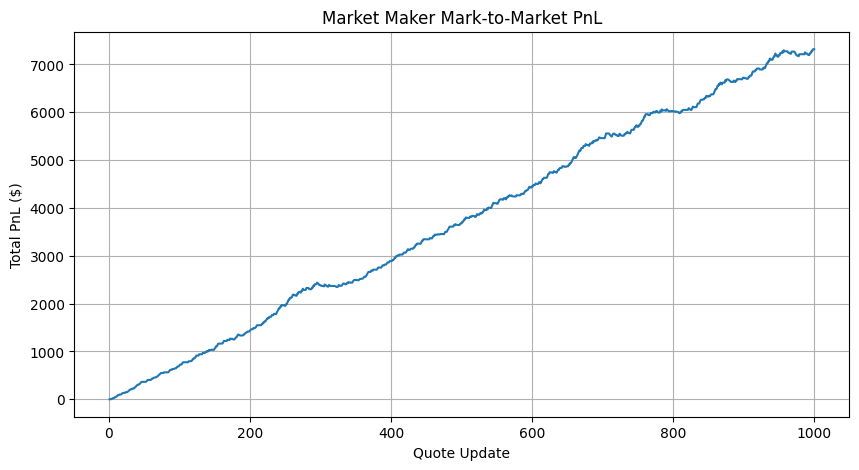

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(
    history["update_number"],
    history["total_pnl"],
)
plt.xlabel("Quote Update")
plt.ylabel("Total PnL ($)")
plt.title("Market Maker Mark-to-Market PnL")
plt.grid(True)
plt.show()

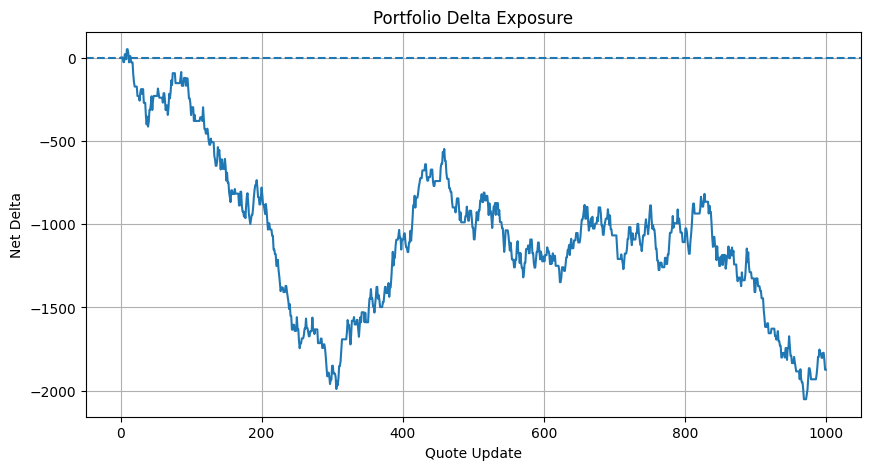

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(
    history["update_number"],
    history["net_delta"],
)
plt.axhline(0, linestyle="--")
plt.xlabel("Quote Update")
plt.ylabel("Net Delta")
plt.title("Portfolio Delta Exposure")
plt.grid(True)
plt.show()

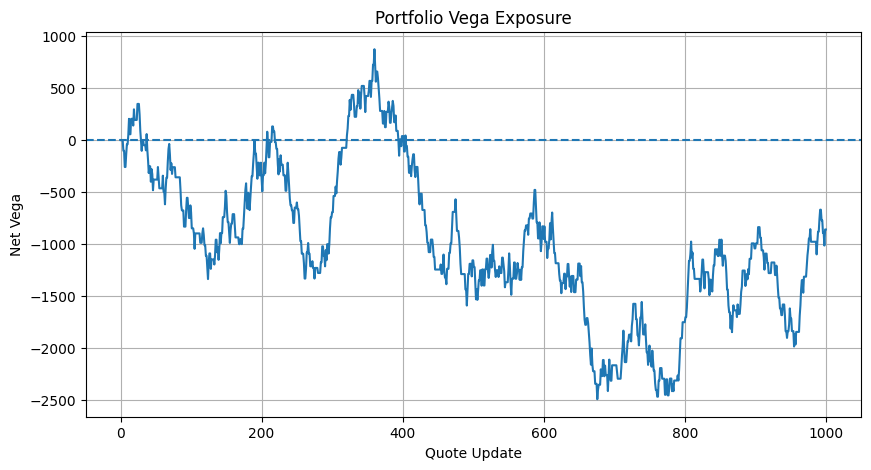

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(
    history["update_number"],
    history["net_vega"],
)
plt.axhline(0, linestyle="--")
plt.xlabel("Quote Update")
plt.ylabel("Net Vega")
plt.title("Portfolio Vega Exposure")
plt.grid(True)
plt.show()

In [13]:
assert len(history) == 1000
assert history["quoted_ask"].ge(history["quoted_bid"]).all()
assert history["fill_probability"].between(0, 1).all()
assert history["total_pnl"].notna().all()

print("Core simulation checks passed.")

Core simulation checks passed.
